In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
from IPython.display import display, Markdown, HTML

In [2]:
play_store_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\Play Store Data.csv")
play_store_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
reviews_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\User Reviews.csv")
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [4]:
print("Rows:", play_store_df.shape[0])
print("Columns:", play_store_df.shape[1])

play_store_df.info()

Rows: 10841
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


In [5]:
# Remove duplicate apps
play_store_df = play_store_df.drop_duplicates(subset="App")

# Convert Reviews to numeric
play_store_df["Reviews"] = pd.to_numeric(
    play_store_df["Reviews"],
    errors="coerce"
)

# Convert Rating to numeric
play_store_df["Rating"] = pd.to_numeric(
    play_store_df["Rating"],
    errors="coerce"
)

# Convert Installs to numeric
play_store_df = play_store_df[
    play_store_df["Installs"] != "Free"
]

play_store_df["Installs_Num"] = (
    play_store_df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)
)

# Convert Last Updated to datetime
play_store_df["Last Updated"] = pd.to_datetime(
    play_store_df["Last Updated"],
    errors="coerce"
)

play_store_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Num
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,10000.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,500000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,5000000.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,50000000.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,100000.0


In [6]:
# Remove completely empty rows
reviews_df = reviews_df.dropna(how="all")

print("User Reviews data cleaned successfully.")
print("Remaining rows:", len(reviews_df))

User Reviews data cleaned successfully.
Remaining rows: 64295


In [7]:
total_apps = play_store_df["App"].nunique()

total_installs = play_store_df["Installs_Num"].sum()

average_rating = play_store_df["Rating"].mean()

total_reviews = play_store_df["Reviews"].sum()

print("Total Apps:", total_apps)
print("Total Installs:", f"{total_installs:,.0f}")
print("Average Rating:", f"{average_rating:.2f}")
print("Total Reviews:", f"{total_reviews:,.0f}")

Total Apps: 9659
Total Installs: 75,122,937,527
Average Rating: 4.17
Total Reviews: 2,092,067,574


In [8]:
display(Markdown("""
# 📊 Google Play Store Analytics Dashboard

### Internship Project

This dashboard provides interactive analysis of Google Play Store applications,
including installs, ratings, reviews, application types, and category performance.
"""))


# 📊 Google Play Store Analytics Dashboard

### Internship Project

This dashboard provides interactive analysis of Google Play Store applications,
including installs, ratings, reviews, application types, and category performance.


In [9]:
total_apps = play_store_df["App"].nunique()
total_installs = play_store_df["Installs_Num"].sum()
average_rating = play_store_df["Rating"].mean()
total_reviews = play_store_df["Reviews"].sum()

display(HTML(f"""
<div style="display:flex; gap:15px; margin:20px 0;">

<div style="flex:1; padding:20px; border-radius:10px;
            background:#f0f4f8; text-align:center;">
<h3>Total Apps</h3>
<h2>{total_apps:,}</h2>
</div>

<div style="flex:1; padding:20px; border-radius:10px;
            background:#f0f4f8; text-align:center;">
<h3>Total Installs</h3>
<h2>{total_installs:,.0f}</h2>
</div>

<div style="flex:1; padding:20px; border-radius:10px;
            background:#f0f4f8; text-align:center;">
<h3>Average Rating</h3>
<h2>{average_rating:.2f} ⭐</h2>
</div>

<div style="flex:1; padding:20px; border-radius:10px;
            background:#f0f4f8; text-align:center;">
<h3>Total Reviews</h3>
<h2>{total_reviews:,.0f}</h2>
</div>

</div>
"""))

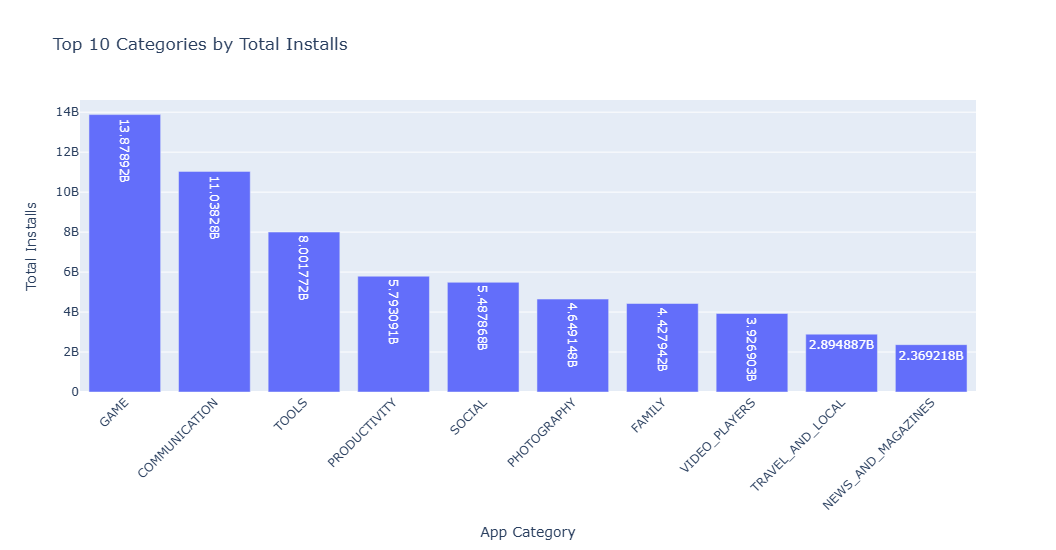

In [10]:
# Graph 1 - Top 10 Categories by Total Installs

category_installs = (
    play_store_df
    .groupby("Category")["Installs_Num"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    category_installs,
    x="Category",
    y="Installs_Num",
    title="Top 10 Categories by Total Installs",
    labels={
        "Category": "App Category",
        "Installs_Num": "Total Installs"
    },
    text_auto=True
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=550
)

fig.show()

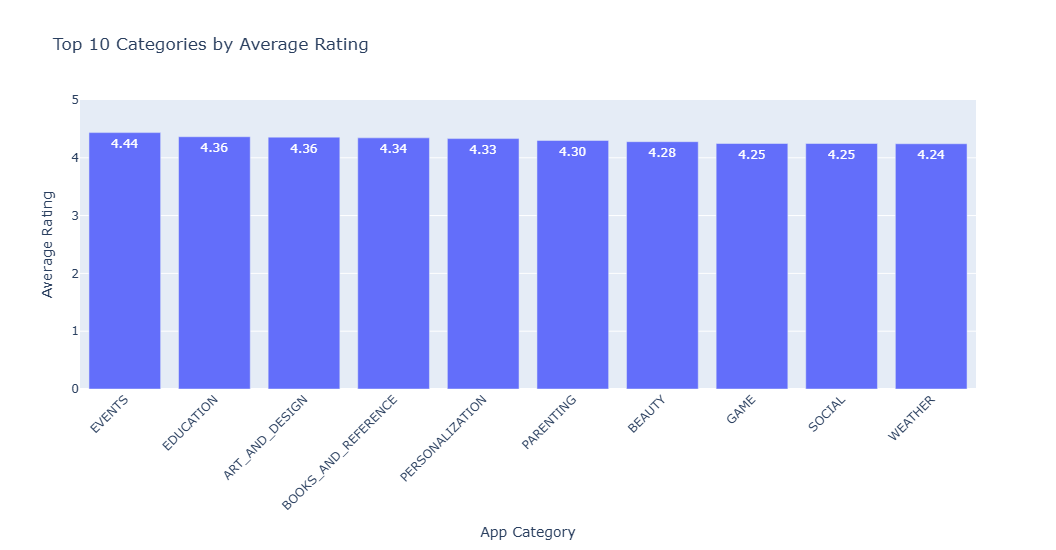

In [11]:
# Graph 2 - Top 10 Categories by Average Rating

category_rating = (
    play_store_df
    .dropna(subset=["Rating"])
    .groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    category_rating,
    x="Category",
    y="Rating",
    title="Top 10 Categories by Average Rating",
    labels={
        "Category": "App Category",
        "Rating": "Average Rating"
    },
    text_auto=".2f"
)

fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_range=[0, 5],
    height=550
)

fig.show()

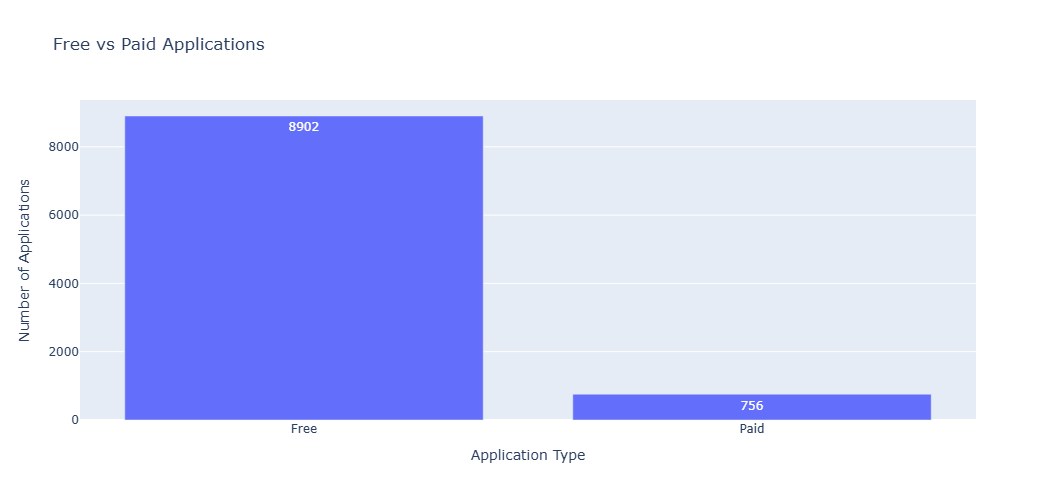

In [12]:
# Graph 3 - Free vs Paid Applications

type_counts = (
    play_store_df["Type"]
    .value_counts()
    .reset_index()
)

type_counts.columns = ["Type", "App_Count"]

fig = px.bar(
    type_counts,
    x="Type",
    y="App_Count",
    title="Free vs Paid Applications",
    labels={
        "Type": "Application Type",
        "App_Count": "Number of Applications"
    },
    text_auto=True
)

fig.update_layout(
    height=500
)

fig.show()

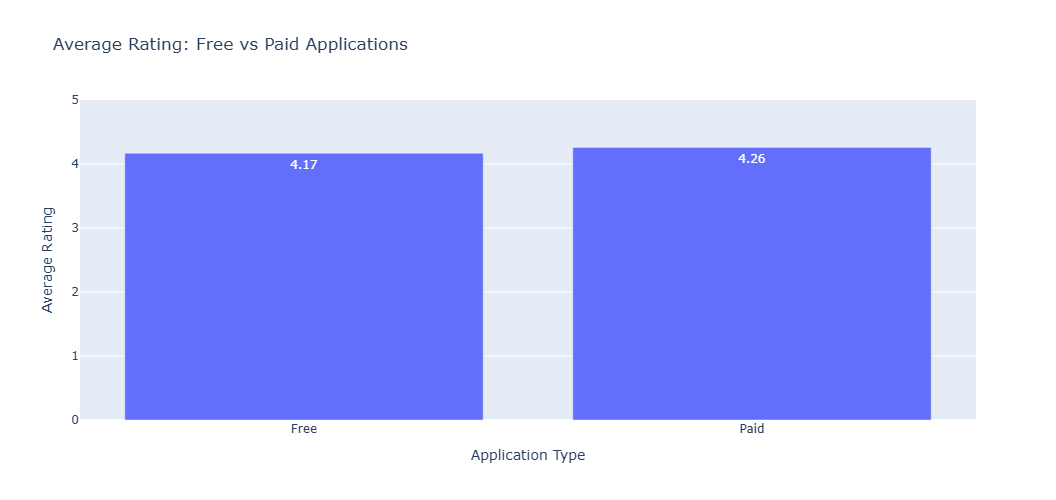

In [13]:
# Graph 4 - Average Rating: Free vs Paid

type_rating = (
    play_store_df
    .dropna(subset=["Rating"])
    .groupby("Type")["Rating"]
    .mean()
    .reset_index()
)

fig = px.bar(
    type_rating,
    x="Type",
    y="Rating",
    title="Average Rating: Free vs Paid Applications",
    labels={
        "Type": "Application Type",
        "Rating": "Average Rating"
    },
    text_auto=".2f"
)

fig.update_layout(
    yaxis_range=[0, 5],
    height=500
)

fig.show()

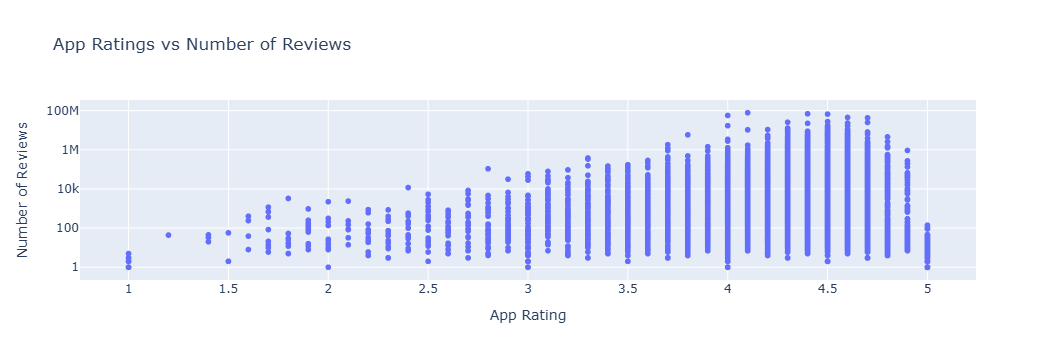

In [14]:
# Graph 5 - Reviews vs Rating

rating_reviews = play_store_df.dropna(
    subset=["Rating", "Reviews"]
).copy()

fig = px.scatter(
    rating_reviews,
    x="Rating",
    y="Reviews",
    title="App Ratings vs Number of Reviews",
    labels={
        "Rating": "App Rating",
        "Reviews": "Number of Reviews"
    },
    hover_data=["App", "Category", "Type"]
)

fig.update_yaxes(type="log")

fig.show()

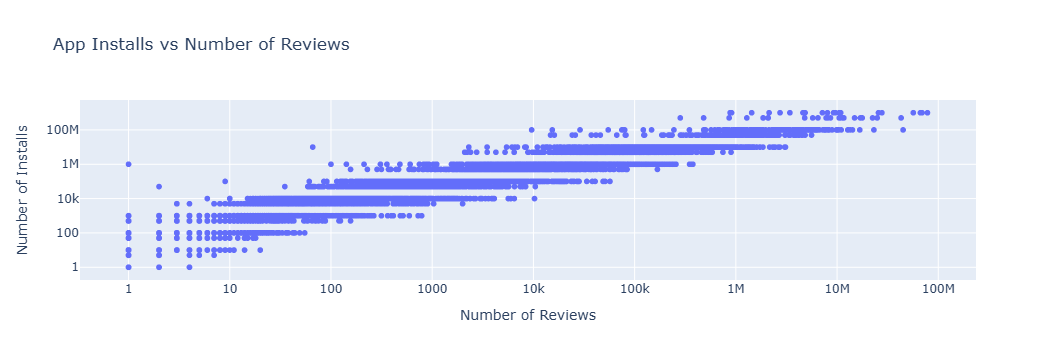

In [15]:
# Graph 6 - Installs vs Reviews

installs_reviews = play_store_df.dropna(
    subset=["Installs_Num", "Reviews"]
).copy()

fig = px.scatter(
    installs_reviews,
    x="Reviews",
    y="Installs_Num",
    title="App Installs vs Number of Reviews",
    labels={
        "Reviews": "Number of Reviews",
        "Installs_Num": "Number of Installs"
    },
    hover_data=["App", "Category", "Rating"]
)

fig.update_xaxes(type="log")
fig.update_yaxes(type="log")

fig.show()

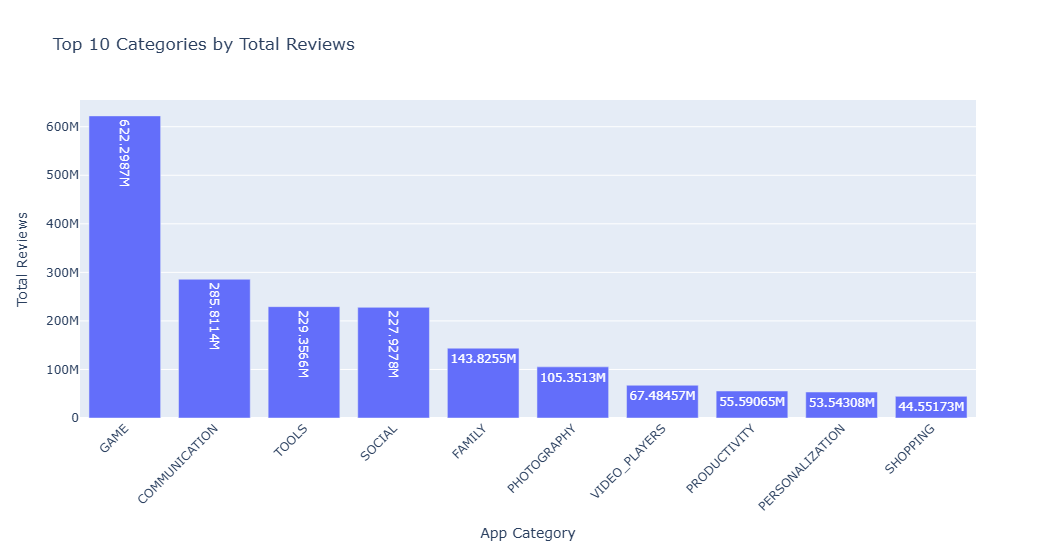

In [16]:
# Graph 7 - Top 10 Categories by Total Reviews

category_reviews = (
    play_store_df
    .groupby("Category")["Reviews"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    category_reviews,
    x="Category",
    y="Reviews",
    title="Top 10 Categories by Total Reviews",
    labels={
        "Category": "App Category",
        "Reviews": "Total Reviews"
    },
    text_auto=True
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=550
)

fig.show()

In [17]:
# Task 6 - Data Preparation

task6_df = play_store_df.copy()

# Convert Size to MB
def convert_size(value):
    value = str(value).strip()

    if value == "Varies with device":
        return np.nan

    if value.endswith("M"):
        return float(value.replace("M", ""))

    if value.endswith("k"):
        return float(value.replace("k", "")) / 1024

    return np.nan


task6_df["Size_MB"] = task6_df["Size"].apply(convert_size)

# Apply Size >= 10 MB
task6_df = task6_df[
    task6_df["Size_MB"] >= 10
].copy()

# Keep applications updated in January
task6_df = task6_df[
    task6_df["Last Updated"].dt.month == 1
].copy()

# Category-wise calculations
task6_summary = (
    task6_df
    .groupby("Category")
    .agg(
        Average_Rating=("Rating", "mean"),
        Total_Reviews=("Reviews", "sum"),
        Total_Installs=("Installs_Num", "sum")
    )
    .reset_index()
)

# Average rating >= 4.0
task6_summary = task6_summary[
    task6_summary["Average_Rating"] >= 4.0
].copy()

# Top 10 categories by installs
task6_summary = (
    task6_summary
    .sort_values("Total_Installs", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

task6_summary

,Category,Average_Rating,Total_Reviews,Total_Installs
0,SPORTS,4.342857,1982017.0,120511100.0
1,GAME,4.251515,2412245.0,117291000.0
2,FAMILY,4.188889,3006890.0,111221180.0
3,ENTERTAINMENT,4.300000,869111.0,21000000.0
4,PERSONALIZATION,4.475000,156004.0,15061000.0
5,LIFESTYLE,4.050000,53376.0,6171560.0
6,EDUCATION,4.400000,57645.0,2000000.0
7,COMMUNICATION,4.050000,15398.0,1011000.0
8,SHOPPING,4.200000,9975.0,1000000.0
9,ART_AND_DESIGN,4.100000,2167.0,620000.0


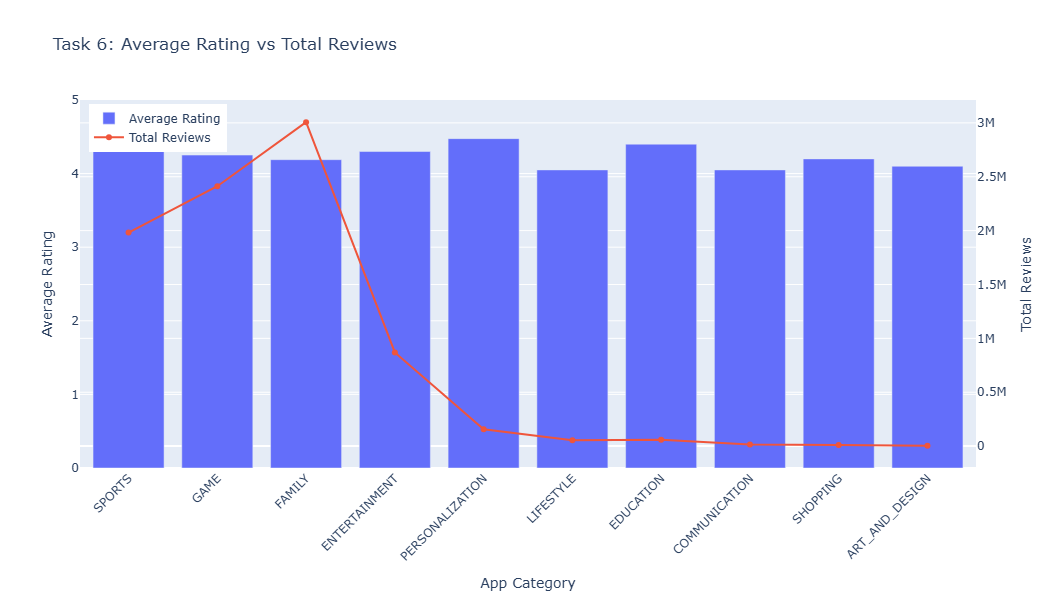

In [18]:
# Graph 8 - Task 6 Dual Axis Chart

fig = go.Figure()

# Average Rating
fig.add_trace(
    go.Bar(
        x=task6_summary["Category"],
        y=task6_summary["Average_Rating"],
        name="Average Rating",
        yaxis="y1"
    )
)

# Total Reviews
fig.add_trace(
    go.Scatter(
        x=task6_summary["Category"],
        y=task6_summary["Total_Reviews"],
        name="Total Reviews",
        mode="lines+markers",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Task 6: Average Rating vs Total Reviews",
    
    xaxis=dict(
        title="App Category",
        tickangle=-45
    ),
    
    yaxis=dict(
        title="Average Rating",
        range=[0, 5]
    ),
    
    yaxis2=dict(
        title="Total Reviews",
        overlaying="y",
        side="right"
    ),
    
    legend=dict(
        x=0.01,
        y=0.99
    ),
    
    height=600
)

fig.show()

In [19]:
display(Markdown("""
## 📌 Key Insights

- The Google Play Store contains applications across a wide range of categories.
- A small number of categories account for a large share of total installations and reviews.
- Free applications are considerably more common than paid applications.
- Application ratings generally provide an indication of user satisfaction, while review counts indicate user engagement.
- The comparison between installs, reviews, and ratings helps identify categories with strong user engagement.
- The Task 6 analysis compares category-wise average ratings with total reviews after applying the required filters.
- Interactive Plotly visualizations make it easier to explore application performance and category-level trends.

## ✅ Conclusion

The dashboard provides a consolidated view of Google Play Store application
performance using ratings, reviews, installs, categories, and application type.
The analysis demonstrates how data cleaning, aggregation, and visualization
can be used to generate meaningful insights from real-world application data.
"""))


## 📌 Key Insights

- The Google Play Store contains applications across a wide range of categories.
- A small number of categories account for a large share of total installations and reviews.
- Free applications are considerably more common than paid applications.
- Application ratings generally provide an indication of user satisfaction, while review counts indicate user engagement.
- The comparison between installs, reviews, and ratings helps identify categories with strong user engagement.
- The Task 6 analysis compares category-wise average ratings with total reviews after applying the required filters.
- Interactive Plotly visualizations make it easier to explore application performance and category-level trends.

## ✅ Conclusion

The dashboard provides a consolidated view of Google Play Store application
performance using ratings, reviews, installs, categories, and application type.
The analysis demonstrates how data cleaning, aggregation, and visualization
can be used to generate meaningful insights from real-world application data.
